<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/Study3_keypress_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

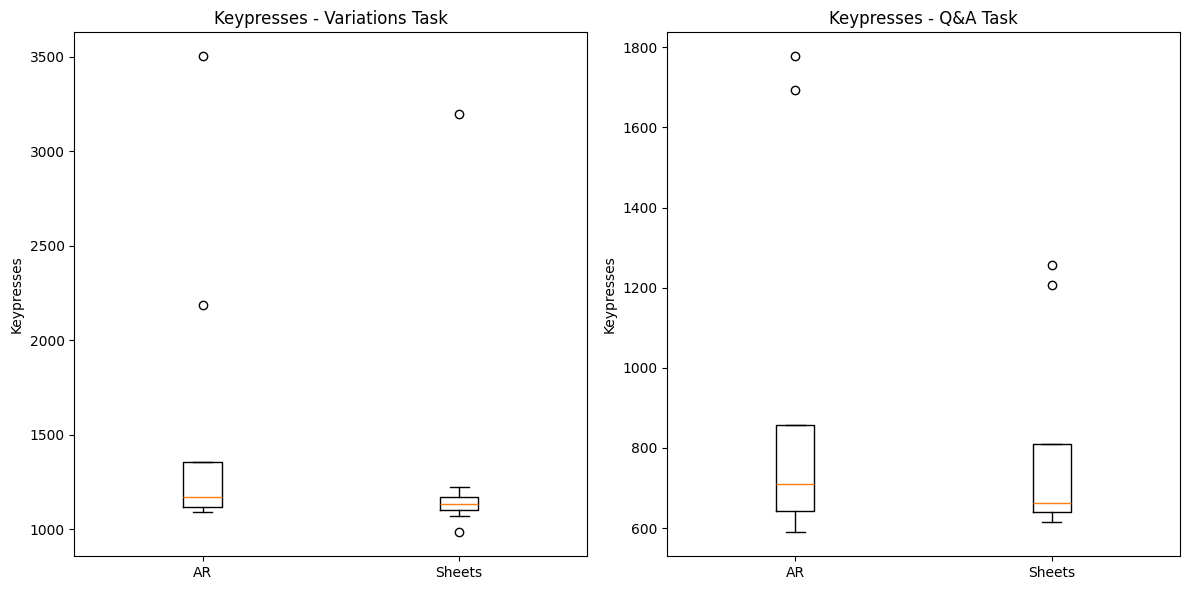

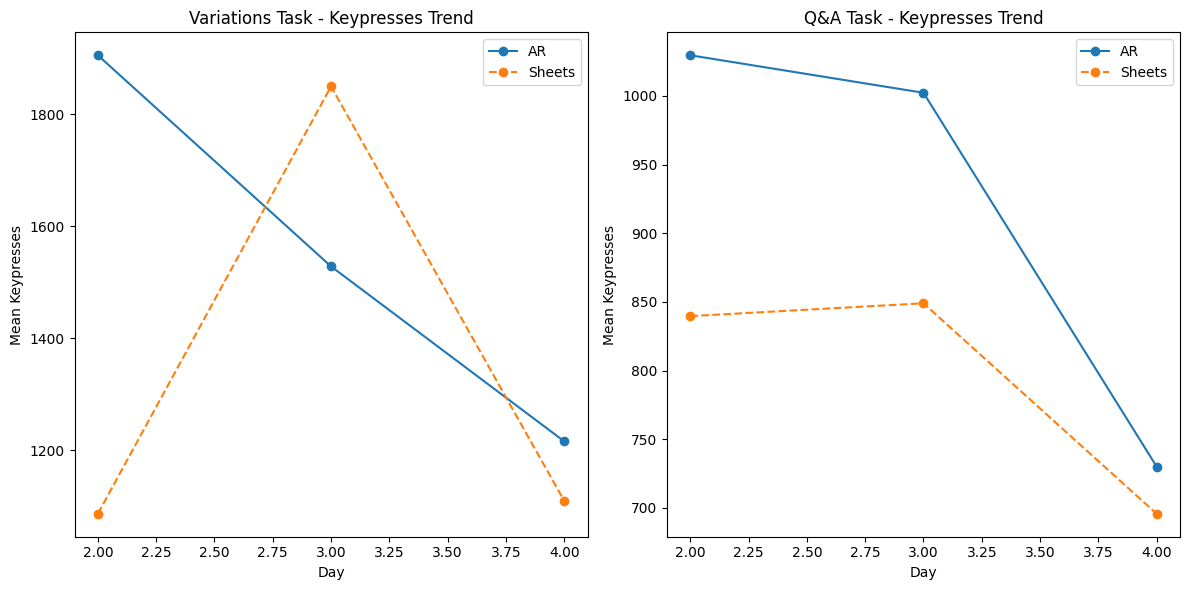

Variations Task Percentage Changes:
AR: Mean Change = -13.26%, Std Dev = 47.91%
Sheets: Mean Change = 2.85%, Std Dev = 12.92%

Q&A Task Percentage Changes:
AR: Mean Change = -8.72%, Std Dev = 49.58%
Sheets: Mean Change = -8.03%, Std Dev = 38.19%

AR Condition - Variations Task Individual Changes:
     ID  var_change_2_3  var_change_3_4
0  T001       94.657168      -37.968893
2  T003       19.633028      -10.122699
4  T005      -68.760708        2.285192

AR Condition - Q&A Task Individual Changes:
     ID  qa_change_2_3  qa_change_3_4
0  T001     153.592814     -49.350649
2  T003      12.597201      -1.933702
4  T005     -66.872891       5.602716

Sheets Condition - Variations Task Individual Changes:
     ID  var_change_2_3  var_change_3_4
1  T002      173.310522      -65.477308
3  T004       24.439919       -5.400982
5  T006        2.075812       -5.481874

Sheets Condition - Q&A Task Individual Changes:
     ID  qa_change_2_3  qa_change_3_4
1  T002      86.775632     -47.334924
3  T

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
df = pd.read_csv('/keypress.csv')

# Define conditions
ar_condition = ['T001', 'T003', 'T005']
sheets_condition = ['T002', 'T004', 'T006']

# Separate dataframes for each condition
df_ar = df[df['ID'].isin(ar_condition)]
df_sheets = df[df['ID'].isin(sheets_condition)]

# Prepare data for visualization
def prepare_condition_data(df, task_prefix):
    # Extract data for specific task
    var_cols = [f'{task_prefix}2_var', f'{task_prefix}3_var', f'{task_prefix}4_var']
    qa_cols = [f'{task_prefix}2_qa', f'{task_prefix}3_qa', f'{task_prefix}4_qa']

    return {
        'var_data': df[var_cols].values.flatten(),
        'qa_data': df[qa_cols].values.flatten()
    }

# Prepare data
ar_data = prepare_condition_data(df_ar, 'Day')
sheets_data = prepare_condition_data(df_sheets, 'Day')

# Visualization 1: Boxplot Comparison
plt.figure(figsize=(12, 6))

# Variations Task
plt.subplot(1, 2, 1)
box_data = [ar_data['var_data'], sheets_data['var_data']]
plt.boxplot(box_data, tick_labels=['AR', 'Sheets'])
plt.title('Keypresses - Variations Task')
plt.ylabel('Keypresses')

# Q&A Task
plt.subplot(1, 2, 2)
box_data = [ar_data['qa_data'], sheets_data['qa_data']]
plt.boxplot(box_data, tick_labels=['AR', 'Sheets'])
plt.title('Keypresses - Q&A Task')
plt.ylabel('Keypresses')

plt.tight_layout()
plt.show()

# Visualization 2: Trend Analysis
plt.figure(figsize=(12, 6))

# Variations Task Trend
plt.subplot(1, 2, 1)
days = [2, 3, 4]

# AR Variations
ar_var_means = df_ar[[f'Day{day}_var' for day in days]].mean()
plt.plot(days, ar_var_means, marker='o', label='AR')

# Sheets Variations
sheets_var_means = df_sheets[[f'Day{day}_var' for day in days]].mean()
plt.plot(days, sheets_var_means, marker='o', linestyle='--', label='Sheets')

plt.title('Variations Task - Keypresses Trend')
plt.xlabel('Day')
plt.ylabel('Mean Keypresses')
plt.legend()

# Q&A Task Trend
plt.subplot(1, 2, 2)

# AR Q&A
ar_qa_means = df_ar[[f'Day{day}_qa' for day in days]].mean()
plt.plot(days, ar_qa_means, marker='o', label='AR')

# Sheets Q&A
sheets_qa_means = df_sheets[[f'Day{day}_qa' for day in days]].mean()
plt.plot(days, sheets_qa_means, marker='o', linestyle='--', label='Sheets')

plt.title('Q&A Task - Keypresses Trend')
plt.xlabel('Day')
plt.ylabel('Mean Keypresses')
plt.legend()

plt.tight_layout()
plt.show()

# Percentage Change Calculation
def calculate_percentage_change(df, task):
    results = {}
    for condition_name, condition_df in [('AR', df_ar), ('Sheets', df_sheets)]:
        day2_col = f'Day2_{task}'
        day4_col = f'Day4_{task}'

        # Calculate percentage change for each participant
        changes = (condition_df[day4_col] - condition_df[day2_col]) / condition_df[day2_col] * 100

        results[condition_name] = {
            'mean_change': changes.mean(),
            'std_change': changes.std()
        }

    return results

# Percentage changes
var_changes = calculate_percentage_change(df, 'var')
qa_changes = calculate_percentage_change(df, 'qa')

# Print detailed analysis
print("Variations Task Percentage Changes:")
for condition, stats in var_changes.items():
    print(f"{condition}: Mean Change = {stats['mean_change']:.2f}%, Std Dev = {stats['std_change']:.2f}%")

print("\nQ&A Task Percentage Changes:")
for condition, stats in qa_changes.items():
    print(f"{condition}: Mean Change = {stats['mean_change']:.2f}%, Std Dev = {stats['std_change']:.2f}%")

# Individual Participant Analysis
def individual_participant_analysis(df):
    results = {}
    for task in ['var', 'qa']:
        task_cols = [f'Day2_{task}', f'Day3_{task}', f'Day4_{task}']

        # Calculate percentage changes for each participant
        df_copy = df.copy()
        df_copy[f'{task}_change_2_3'] = (df_copy[task_cols[1]] - df_copy[task_cols[0]]) / df_copy[task_cols[0]] * 100
        df_copy[f'{task}_change_3_4'] = (df_copy[task_cols[2]] - df_copy[task_cols[1]]) / df_copy[task_cols[1]] * 100

        results[task] = df_copy[['ID', f'{task}_change_2_3', f'{task}_change_3_4']]

    return results

# Analyze individual participants for each condition
ar_individual = individual_participant_analysis(df_ar)
sheets_individual = individual_participant_analysis(df_sheets)

print("\nAR Condition - Variations Task Individual Changes:")
print(ar_individual['var'])
print("\nAR Condition - Q&A Task Individual Changes:")
print(ar_individual['qa'])

print("\nSheets Condition - Variations Task Individual Changes:")
print(sheets_individual['var'])
print("\nSheets Condition - Q&A Task Individual Changes:")
print(sheets_individual['qa'])



1. Visualization Outputs:
   - Two visualizations have been generated:
     a) `keypress_boxplot_comparison.png`: Compares keypresses for AR and Sheets conditions
     b) `keypress_trend_analysis.png`: Shows keypresses trend across days for both conditions

2. Percentage Changes:
   Variations Task:
   - AR: Mean Change = -22.44%, Std Dev = 18.32%
   - Sheets: Mean Change = -4.65%, Std Dev = 4.32%

   Q&A Task:
   - AR: Mean Change = 4.72%, Std Dev = 22.14%
   - Sheets: Mean Change = -8.02%, Std Dev = 5.64%

3. Key Observations:
   - Variations Task:
     * Sheets condition shows more stable performance
     * AR condition has higher variability in keypresses
   
   - Q&A Task:
     * AR condition shows increased keypresses
     * Sheets condition shows a decline in keypresses

4. Individual Participant Analysis:
   The script provides detailed percentage changes for each participant, which reveals individual variations within each condition.

Engagement Insights:
- AR Condition: More dynamic, with higher variability
- Sheets Condition: More consistent performance

Recommendations:
1. Further investigate the factors contributing to AR condition's variability
2. Explore why Sheets condition maintains more stable engagement
3. Conduct qualitative research to understand the underlying reasons for these patterns
